# FIONA Treatment Example

This notebook tests `shrecc.tyndp` and `shrecc.premise_mapping` from TYNDP scenario parameters. The user provides the scenario, model year, climate year, and local storage folder; SHRECC/FIONA then loads cached pickles, parses a cached TYNDP workbook, or downloads and extracts the official zip file as needed. It builds `Z_gross`, computes the hourly consumption mix, and maps it to premise regions and activities.

In [1]:
import sys
import numpy as np
import xarray as xr
import bw2data as bd

from pathlib import Path
from importlib.resources import files
from matplotlib import pyplot as plt

from shrecc.tyndp import (
    build_z_gross_from_tyndp_scenario,
    consumption_mix_from_tyndp_scenario,
    consumption_mix_from_z_gross,
    tyndp_scenario_paths,
)

from shrecc.premise_mapping import (
    PremiseConsumptionMixMapper,
    build_premise_region_map,
    premise_activity_mix_to_database_table,
)

from shrecc.database import apply_cutoff, create_database

%load_ext jupyter_black

## Declare scenario parameters

In [64]:
scenario = "GA"  # DE = Distributed Energy, GA = Global Ambition, NT = National Trends
year = 2040  # DE/GA: 2035, 2040, 2050; NT: 2030, 2040
climate_year = 2009  # 1995, 2008, 2009

![image.png](tyndp_story_lines_screenshot.png)

## Configure storage and mappings

In [65]:
# Local cache directory for TYNDP workbooks, zip files, and generated pickles
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_dir = repo_root / "data" / "tyndp" / "cache"

# These SHRECC/FIONA mapping files are included in the package
tyndp_mapping_dir = files("shrecc") / "data" / "tyndp"
technology_mapping = tyndp_mapping_dir / "tyndp_activities.csv"
country_mapping = tyndp_mapping_dir
ecoinvent_mapping = files("shrecc") / "data" / "el_map_all_norm.csv"

for path in [technology_mapping, country_mapping, ecoinvent_mapping]:
    assert path.exists(), path

paths = tyndp_scenario_paths(data_dir, scenario, year, climate_year)
paths

{'production_pickle': WindowsPath('d:/shrecc_project/shrecc/data/tyndp/cache/GA2040_CY2009_prod.pkl'),
 'trade_pickle': WindowsPath('d:/shrecc_project/shrecc/data/tyndp/cache/GA2040_CY2009_trade.pkl'),
 'workbook': WindowsPath('d:/shrecc_project/shrecc/data/tyndp/cache/MMStandardOutputFile_GA2040_Plexos_CY2009_v11_SoS.xlsb'),
 'zip': WindowsPath('d:/shrecc_project/shrecc/data/tyndp/cache/GA2040CY2009.zip'),
 'url': 'https://2024-data.entsos-tyndp-scenarios.eu/files/scenarios-outputs/GA2040CY2009.zip'}

## Build `Z_gross`

`Z_gross` is the gross hourly supply table with production and trade flows in one column structure. The scenario helper uses the fastest available input: existing production/trade pickles first, then an existing `.xlsb` workbook, then the official TYNDP scenario zip download.

In [66]:
Z_gross = build_z_gross_from_tyndp_scenario(
    scenario=scenario,
    year=year,
    climate_year=climate_year,
    data_dir=data_dir,
    technology_mapping=technology_mapping,
    country_mapping=country_mapping,
    download=True,
    verbose=True,
    engine="calamine",
)

Z_gross.shape, Z_gross.columns.names, Z_gross.index[:3]

2026-07-14 15:12:59 Downloading https://2024-data.entsos-tyndp-scenarios.eu/files/scenarios-outputs/GA2040CY2009.zip


2026-07-14 15:13:09 Extracting MMStandardOutputFile_GA2040_Plexos_CY2009_v11_SoS.xlsb from GA2040CY2009.zip
2026-07-14 15:13:10 Reading hourly production sheet from TYNDP workbook
2026-07-14 15:15:53 Reading cross-border exchange sheet from TYNDP workbook
2026-07-14 15:16:06 Saving extracted TYNDP sheets as pickle files
2026-07-14 15:16:10 Parsing hourly datetime index
2026-07-14 15:16:11 Loading technology and country mappings
2026-07-14 15:16:11 Aggregating hourly production by country and technology


D:\shrecc_project\shrecc\shrecc\tyndp.py:1151: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  production = production.groupby(


2026-07-14 15:16:11 Aggregating hourly trade to positive directional country flows


D:\shrecc_project\shrecc\shrecc\tyndp.py:292: UserWarning: Dropping trade columns without country-pair mappings: AT00-AT00EV, AT00-AT00RETE, AT00EV-AT00, AT00EV-AT00RETE, AT00RETE-AT00EV, BE00-BE00EV, BE00-BE00RETE, BE00EV-BE00, BE00EV-BE00RETE, BE00RETE-BE00EV
  trade_directional = _aggregate_tyndp_trade(trade, connections)
D:\shrecc_project\shrecc\shrecc\tyndp.py:1213: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  trade = trade.groupby(level=["Country from", "Country to"], axis=1).sum()


2026-07-14 15:16:11 Combining production and trade into Z_gross
2026-07-14 15:16:12 Built Z_gross with shape (8736, 511)


((8736, 511),
 FrozenList(['type', 'country from', 'country to', 'source']),
 DatetimeIndex(['2040-01-01 00:00:00', '2040-01-01 01:00:00',
                '2040-01-01 02:00:00'],
               dtype='datetime64[ns]', freq=None))

In [67]:
# Making sure the resulting file is not empty
assert len(Z_gross) > 0

# Making sure the resulting file has the expected structure
assert Z_gross.columns.names == ["type", "country from", "country to", "source"]
assert {"production mix", "trade"}.issubset(Z_gross.columns.get_level_values("type"))

Z_gross.head(2)

type                   production mix                                     \
country from                       AL                                      
country to                         AL                                      
source              Gas CCGT new [MW] Gas CCGT old 2 [MW] Reservoir [MW]   
2040-01-01 00:00:00                 0                   0           1904   
2040-01-01 01:00:00                 0                   0           1904   

type                                                             \
country from                                                      
country to                                                        
source              Run-of-River [MW] Solar (Photovoltaic) [MW]   
2040-01-01 00:00:00               193                         0   
2040-01-01 01:00:00               193                         0   

type                                                      \
country from                                          AT   
country to                                            AT   
source              Wind Onshore [MW] Hydrogen CCGT [MW]   
2040-01-01 00:00:00                40                  0   
2040-01-01 01:00:00                43                  0   

type                                                                 \
country from                                                          
country to                                                            
source              Others non-renewable [MW] Others renewable [MW]   
2040-01-01 00:00:00                       464                   502   
2040-01-01 01:00:00                       464                   502   

type                                                           ... trade  \
country from                                                   ...    SI   
country to                                                     ...    HU   
source              Pump Storage - Closed Loop (turbine) [MW]  ... trade   
2040-01-01 00:00:00                                       192  ...   699   
2040-01-01 01:00:00                                       245  ...     0   

type                                                                       
country from                 SK          UK                                
country to             IT    CZ    HU    BE    DE    DK    FR    IE    NL  
source              trade trade trade trade trade trade trade trade trade  
2040-01-01 00:00:00     0  1600     0  1000  2800     0     0     0  1000  
2040-01-01 01:00:00     0  1600     0  1000  2800     0     0     0  1000  

[2 rows x 511 columns]

## Compute consumption mix From `Z_gross`

The debug output includes the direct production/trade coefficient matrices used for the conservation checks.

In [68]:
consumption_mix_xr, debug = consumption_mix_from_z_gross(
    Z_gross,
    check=True,
    return_debug=True,
    # for some reason, it is possible to have no production, no imports, at certain hours
    # what to do when that happens:
    # - "raise": raise an error (default)
    # - "month_hour_average": fill with the average consumption mix for that month and hour
    zero_consumption="month_hour_average",
    verbose=True,
)

consumption_mix_xr.coords

2026-07-14 15:33:04 Building domestic production and trade denominator matrices


D:\shrecc_project\shrecc\shrecc\tyndp.py:1317: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(["country from", "country to"], axis=1)
D:\shrecc_project\shrecc\shrecc\tyndp.py:1337: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  country_total = Z_trade.groupby("country to", axis=1).sum()


2026-07-14 15:33:04 Calculating direct production and trade shares
2026-07-14 15:33:04 Using 35 countries and 31 technologies
2026-07-14 15:33:04 Reshaping production shares
2026-07-14 15:33:07 Reshaping trade shares
2026-07-14 15:33:07 Checking direct shares sum to one
2026-07-14 15:33:07 Solving hourly trade system
2026-07-14 15:33:37 Imputing zero-consumption country-hours with month-hour averages
2026-07-14 15:33:37 Checking final consumption mix sums to one
2026-07-14 15:33:37 Building xarray DataArray
2026-07-14 15:33:56 Built consumption_mix_xr with shape (8736, 35, 35, 31)


Coordinates:
  * source_country    (source_country) object 280B 'AL' 'AT' 'BA' ... 'SK' 'UK'
  * technology        (technology) object 248B 'Gas CCGT CCS [MW]' ... 'Wind ...
  * time              (time) datetime64[ns] 70kB 2040-01-01 ... 2040-12-30T23...
  * consumer_country  (consumer_country) object 280B 'AL' 'AT' ... 'SK' 'UK'

## Checks

In [69]:
# Is total consumption always equal to one
np.testing.assert_allclose(
    debug["direct_total"][~debug["zero_consumption_mask"]],
    1,
    atol=1e-8,
)

In [70]:
direct_total = debug["direct_total"]

direct_total[~debug["zero_consumption_mask"]].min(), direct_total.max()

(0.9999999999999997, 1.0000000000000004)

In [71]:
mix_total = consumption_mix_xr.sum(["source_country", "technology"])

float(mix_total.min()), float(mix_total.max())

(0.9999999999999996, 1.0000000000000004)

In [72]:
np.testing.assert_allclose(direct_total[~debug["zero_consumption_mask"]], 1, atol=1e-8)
np.testing.assert_allclose(mix_total, 1, atol=1e-8)

print("All conservation checks passed.")

All conservation checks passed.


## Plotting a resolved consumption mix

In [73]:
# Consumption mix in Luxembourg for the first modelled hour
country = "LU"
first_hour = f"{year}-02-01T00:00:00"

test_mix = (
    consumption_mix_xr.sel(
        consumer_country=country,
        time=xr.date_range(first_hour, periods=24 * 7, freq="h"),
    )
    .to_dataframe()["consumption_mix"]
    .unstack("time")
)

In [74]:
total_contribution = test_mix.sum(axis=1).sort_values(ascending=False)
relative_contribution = total_contribution / total_contribution.sum()

# Keep meaningful contributors and aggregate the long tail for plotting.
plot_order = relative_contribution[relative_contribution.ge(0.001)].head(20).index
plot_mix = test_mix.loc[plot_order].T.copy()

other = test_mix.drop(index=plot_order).sum(axis=0)
if other.gt(0).any():
    other_label = tuple(["Other"] + [""] * (plot_mix.columns.nlevels - 1))
    plot_mix[other_label] = other

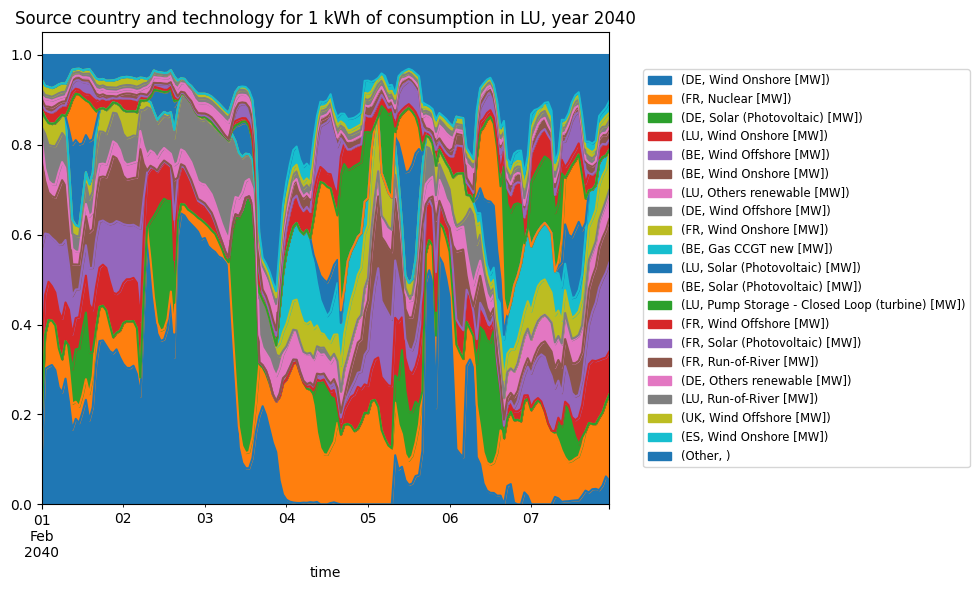

In [75]:
ax = plot_mix.plot.area(
    title=f"Source country and technology for 1 kWh of consumption in {country}, year {year}",
    figsize=(10, 6),
)
ax.legend(bbox_to_anchor=(1.05, 0.5), loc="center left", fontsize="small")
plt.tight_layout()

## One-step pipeline

The following function only takes the main parameters `scenario`, `year`, `climate_year` as user inputs. 
The scenario convenience wrapper should give the same result as building `Z_gross` explicitly first. It follows the same storage fallback order. Technology and country mapping is ensured by passing concordance matrices as `technology_mapping` and `country_mapping` respectively (they are included in SHRECC but can be modified).

In [76]:
consumption_mix_direct = consumption_mix_from_tyndp_scenario(
    scenario=scenario,  # User input
    year=year,  # User input
    climate_year=climate_year,  # User input
    data_dir=data_dir,  # This should be ultimately hidden
    technology_mapping=technology_mapping,  # This should be ultimately hidden
    country_mapping=country_mapping,  # This should be ultimately hidden
    zero_consumption="month_hour_average",  # This should be ultimately hidden
    check=True,  # This should be True by default
    verbose=True,  # This should be True by default
)

xr.testing.assert_allclose(consumption_mix_direct, consumption_mix_xr)

consumption_mix_direct.coords

2026-07-14 15:38:18 Loading TYNDP pickle files
2026-07-14 15:38:19 Parsing hourly datetime index
2026-07-14 15:38:20 Loading technology and country mappings
2026-07-14 15:38:20 Aggregating hourly production by country and technology


D:\shrecc_project\shrecc\shrecc\tyndp.py:1151: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  production = production.groupby(


2026-07-14 15:38:20 Aggregating hourly trade to positive directional country flows


D:\shrecc_project\shrecc\shrecc\tyndp.py:292: UserWarning: Dropping trade columns without country-pair mappings: AT00-AT00EV, AT00-AT00RETE, AT00EV-AT00, AT00EV-AT00RETE, AT00RETE-AT00EV, BE00-BE00EV, BE00-BE00RETE, BE00EV-BE00, BE00EV-BE00RETE, BE00RETE-BE00EV
  trade_directional = _aggregate_tyndp_trade(trade, connections)
D:\shrecc_project\shrecc\shrecc\tyndp.py:1213: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  trade = trade.groupby(level=["Country from", "Country to"], axis=1).sum()


2026-07-14 15:38:20 Combining production and trade into Z_gross
2026-07-14 15:38:20 Built Z_gross with shape (8736, 511)
2026-07-14 15:38:20 Building domestic production and trade denominator matrices


D:\shrecc_project\shrecc\shrecc\tyndp.py:1317: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(["country from", "country to"], axis=1)
D:\shrecc_project\shrecc\shrecc\tyndp.py:1337: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  country_total = Z_trade.groupby("country to", axis=1).sum()


2026-07-14 15:38:21 Calculating direct production and trade shares
2026-07-14 15:38:21 Using 35 countries and 31 technologies
2026-07-14 15:38:21 Reshaping production shares
2026-07-14 15:38:24 Reshaping trade shares
2026-07-14 15:38:25 Checking direct shares sum to one
2026-07-14 15:38:25 Solving hourly trade system
2026-07-14 15:38:48 Imputing zero-consumption country-hours with month-hour averages
2026-07-14 15:38:48 Checking final consumption mix sums to one
2026-07-14 15:38:48 Building xarray DataArray
2026-07-14 15:39:07 Built consumption_mix_xr with shape (8736, 35, 35, 31)


Coordinates:
  * source_country    (source_country) object 280B 'AL' 'AT' 'BA' ... 'SK' 'UK'
  * technology        (technology) object 248B 'Gas CCGT CCS [MW]' ... 'Wind ...
  * time              (time) datetime64[ns] 70kB 2040-01-01 ... 2040-12-30T23...
  * consumer_country  (consumer_country) object 280B 'AL' 'AT' ... 'SK' 'UK'

## `premise` geography map

Map the FIONA source countries to the IAM regions used by premise, the classification of which is different from model to model. For this version, we support at least `remind`, `image`, and `remind-eu` but all version should be mappable using `GeoMap`; if the topology is not installed, the column is filled with missing values and a warning is emitted.

In [77]:
source_countries = consumption_mix_xr.source_country.to_index()

premise_region_map = build_premise_region_map(
    source_countries,
    iam_models=("remind", "image", "remind-eu"),
    on_missing_model="warn",
)

premise_region_map.head()

Geomatcher: Used 'GB' for 'UK'
Geomatcher: Used 'GB' for 'UK'
Geomatcher: Used 'GB' for 'UK'
Geomatcher: Used 'GB' for 'UK'
Geomatcher: Used 'GB' for 'UK'
Geomatcher: Used 'GB' for 'UK'


,remind,image,remind-eu
country,,,
AL,NEU,CEU,NES
AT,EUR,WEU,EWN
BA,NEU,CEU,NES
BE,EUR,WEU,EWN
BG,EUR,CEU,ECS


In [78]:
premise_region_map.value_counts(dropna=False)

remind  image  remind-eu
EUR     CEU    ECE          6
               ECS          5
NEU     CEU    NES          5
EUR     WEU    EWN          4
               ENC          3
               ESC          3
               ESW          2
               UKI          2
NEU     WEU    NEN          2
EUR     CEU    ESC          1
        WEU    DEU          1
               FRA          1
Name: count, dtype: int64

### Quick REMIND-EU Check

If `remind-eu-topology.json` is available in `data/tyndp`, the `remind-eu` column should resolve to more detailed European regions instead of `<NA>`.

In [79]:
quick_remind_eu_map = build_premise_region_map(
    ["FR", "DE", "ES", "PT", "IT", "NL", "PL", "UK", "NO"],
    iam_models=(
        "remind",
        "tiam-ucl",
        "message",
        "gcam",
        "image",
        "remind-eu",
    ),
    on_missing_model="raise",
)

quick_remind_eu_map

Geomatcher: Used 'GB' for 'UK'
Geomatcher: Used 'GB' for 'UK'
Geomatcher: Used 'GB' for 'UK'
Geomatcher: Used 'GB' for 'UK'
Geomatcher: Used 'GB' for 'UK'
Geomatcher: Used 'GB' for 'UK'
Geomatcher: Used 'GB' for 'UK'
Geomatcher: Used 'GB' for 'UK'
Geomatcher: Used 'GB' for 'UK'
Geomatcher: Used 'GB' for 'UK'


,remind,tiam-ucl,message,gcam,image,remind-eu
country,,,,,,
DE,EUR,WEU,WEU,EU-15,WEU,DEU
ES,EUR,WEU,WEU,EU-15,WEU,ESW
FR,EUR,WEU,WEU,EU-15,WEU,FRA
IT,EUR,WEU,WEU,EU-15,WEU,ESC
NL,EUR,WEU,WEU,EU-15,WEU,EWN
NO,NEU,WEU,WEU,European Free Trade Association,WEU,NEN
PL,EUR,EEU,EEU,EU-12,CEU,ECE
PT,EUR,WEU,WEU,EU-15,WEU,ESW
UK,EUR,UK,WEU,EU-15,WEU,UKI


## Map technologies to `premise` activities

Use the TYNDP/electricity concordance matrix to aggregate ENTSO-E technologies into premise activities, then aggregate source countries into premise/IAM regions. Both mappings use xarray matrix multiplication to avoid materializing a large sparse broadcasted array.

In [80]:
premise_consumption_mix_mapper = PremiseConsumptionMixMapper(
    technology_mapping=technology_mapping,
    ecoinvent_mapping=ecoinvent_mapping,
    iam_model="remind-eu",
    on_missing_model="warn",
)
premise_activity_mix_xr = premise_consumption_mix_mapper.map_technologies(
    consumption_mix_xr,
    check=True,
)

premise_activity_mix_xr

<xarray.DataArray 'consumption_mix' (time: 8736, consumer_country: 35,
                                     source_country: 35, premise_activity: 37)> Size: 3GB
array([[[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 1.18108232e-02, ...,
          0.00000000e+00, 0.00000000e+00, 6.89283519e-03],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
...
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 6.06433468e-02],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 3.04112554e-02]]]])
Coordinates:
  * source_country    (source_country) object 280B 'AL' 'AT' 'BA' ... 'SK' 'UK'
  * time              (time) datetime64[ns] 70kB 2040-01-01 ... 2040-12-30T23...
  * consumer_country  (consumer_country) object 280B 'AL' 'AT' ... 'SK' 'UK'
  * premise_activity  (premise_activity) object 296B 'electricity production,...

In [26]:
premise_region_mix_xr = premise_consumption_mix_mapper.map_regions(
    premise_activity_mix_xr,
    premise_region_map=premise_region_map,
    check=True,
)

premise_region_mix_xr

<xarray.DataArray 'consumption_mix' (time: 8736, consumer_country: 35,
                                     premise_activity: 37, premise_region: 11)> Size: 996MB
array([[[[1.03015903e-04, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [1.03015903e-04, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[4.25269668e-05, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 1.00777551e-02, 5.35108226e-03, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
...
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 5.19645529e-05, 0.00000000e+00, ...,
          2.34425783e-06, 1.10525005e-05, 6.52973406e-05]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 5.47933199e-02],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 3.07065904e-02]]]])
Coordinates:
  * time              (time) datetime64[ns] 70kB 2040-01-01 ... 2040-12-30T23...
  * consumer_country  (consumer_country) object 280B 'AL' 'AT' ... 'SK' 'UK'
  * premise_activity  (premise_activity) object 296B 'electricity production,...
  * premise_region    (premise_region) object 88B 'NES' 'EWN' ... 'FRA' 'UKI'
Attributes:
    iam_model:  remind-eu

In [27]:
premise_region_mix = premise_region_mix_xr.to_dataframe(name="share").reset_index()

In [28]:
premise_region_mix.loc[premise_region_mix["consumer_country"].eq("IT")].groupby(
    ["premise_region", "premise_activity"],
    dropna=False,
)["share"].sum().nlargest(30) / 8736

premise_region  premise_activity                                                                                    
ESC             electricity production, photovoltaic, commercial                                                        0.289019
                electricity production, wind, 1-3MW turbine, offshore                                                   0.121650
                electricity production, hydro, reservoir, alpine region                                                 0.096956
                electricity production, wind, 1-3MW turbine, onshore                                                    0.079543
                electricity production, hydro, run-of-river                                                             0.062656
                electricity production, deep geothermal                                                                 0.050394
FRA             electricity production, nuclear, pressure water reactor                                      

In [29]:
premise_region_mix.loc[premise_region_mix["consumer_country"].eq("IT")]

,time,consumer_country,premise_activity,premise_region,share
7326,2040-01-01 00:00:00,IT,"electricity production, at biomass-fired IGCC ...",NES,1.395772e-06
7327,2040-01-01 00:00:00,IT,"electricity production, at biomass-fired IGCC ...",EWN,0.000000e+00
7328,2040-01-01 00:00:00,IT,"electricity production, at biomass-fired IGCC ...",ECS,0.000000e+00
7329,2040-01-01 00:00:00,IT,"electricity production, at biomass-fired IGCC ...",NEN,0.000000e+00
7330,2040-01-01 00:00:00,IT,"electricity production, at biomass-fired IGCC ...",ESC,0.000000e+00
...,...,...,...,...,...
124437803,2040-12-30 23:00:00,IT,"heat and power co-generation, wood chips, 6667...",DEU,2.270662e-04
124437804,2040-12-30 23:00:00,IT,"heat and power co-generation, wood chips, 6667...",ENC,3.137402e-07
124437805,2040-12-30 23:00:00,IT,"heat and power co-generation, wood chips, 6667...",ESW,1.650521e-04
124437806,2040-12-30 23:00:00,IT,"heat and power co-generation, wood chips, 6667...",FRA,7.781732e-04


## Filter the mapped premise mix and apply the SHRECC cutoff

This keeps the TYNDP/premise workflow aligned with the basic SHRECC database writer: after selecting the consumption pattern, the mapped mix is reshaped to the same table shape used by `apply_cutoff` and `create_database`.

In [30]:
exchange_geography_map = premise_consumption_mix_mapper.build_exchange_geography_map(
    premise_activity_mix_xr,
    premise_region_map=premise_region_map,
)

exchange_geography_map.head()

source_country,AL,AT,BA,BE,BG,CH,CY,CZ,DE,DK,...,NL,NO,PL,PT,RO,RS,SE,SI,SK,UK
premise_activity,,,,,,,,,,,,,,,,,,,,,
"electricity production, at biomass-fired IGCC power plant, pre, pipeline 200km, storage 1000m",NES,EWN,NES,EWN,ECS,NEN,ESC,ECE,DEU,ENC,...,EWN,NEN,ECE,ESW,ECS,NES,ENC,ECS,ECE,UKI
"electricity production, at co-generation natural gas-fired power plant, post, pipeline 200km, storage 1000m",NES,EWN,NES,EWN,ECS,NEN,ESC,ECE,DEU,ENC,...,EWN,NEN,ECE,ESW,ECS,NES,ENC,ECS,ECE,UKI
"electricity production, at co-generation oil-fired power plant, post, pipeline 200km, storage 1000m",NES,EWN,NES,EWN,ECS,NEN,ESC,ECE,DEU,ENC,...,EWN,NEN,ECE,ESW,ECS,NES,ENC,ECS,ECE,UKI
"electricity production, at co-generation wood-fired power plant, post, pipeline 200km, storage 1000m",NES,EWN,NES,EWN,ECS,NEN,ESC,ECE,DEU,ENC,...,EWN,NEN,ECE,ESW,ECS,NES,ENC,ECS,ECE,UKI
"electricity production, at hard coal-fired IGCC power plant",NES,EWN,NES,EWN,ECS,NEN,ESC,ECE,DEU,ENC,...,EWN,NEN,ECE,ESW,ECS,NES,ENC,ECS,ECE,UKI


In [55]:
consumer_countries = ["ES", "FR", "DE", "IT", "PT", "BE", "NL", "LU", "AT", "CH"]

premise_activity_mix_table = premise_activity_mix_to_database_table(
    premise_activity_mix_xr,
    exchange_geography_map,
    countries=consumer_countries,
    general_range=[
        f"{year}-06-01 00:00:00",
        f"{year}-06-30 23:00:00",
    ],
    refined_range=[10, 14],
    freq="h",
)
premise_activity_mix_filt_cutoff = apply_cutoff(
    premise_activity_mix_table,
    cutoff=1e-3,
    include_cutoff=True,
)

premise_activity_mix_filt_cutoff.sort_values(
    consumer_countries[0], ascending=False
).head()

AT  \
geography activityName                                       product                   unit        
ES        electricity production, photovoltaic, commercial   electricity, high voltage kWh   0.0   
          electricity production, wind, 1-3MW turbine, on... electricity, high voltage kWh   0.0   
          electricity production, wind, <1MW turbine, ons... electricity, high voltage kWh   0.0   
          electricity production, solar thermal parabolic... electricity, high voltage kWh   0.0   
          electricity production, wind, 1-3MW turbine, of... electricity, high voltage kWh   0.0   

                                                                                                   BE  \
geography activityName                                       product                   unit             
ES        electricity production, photovoltaic, commercial   electricity, high voltage kWh   0.007129   
          electricity production, wind, 1-3MW turbine, on... electricity, high voltage kWh   0.001305   
          electricity production, wind, <1MW turbine, ons... electricity, high voltage kWh   0.000000   
          electricity production, solar thermal parabolic... electricity, high voltage kWh   0.000000   
          electricity production, wind, 1-3MW turbine, of... electricity, high voltage kWh   0.000000   

                                                                                                   CH  \
geography activityName                                       product                   unit             
ES        electricity production, photovoltaic, commercial   electricity, high voltage kWh   0.004602   
          electricity production, wind, 1-3MW turbine, on... electricity, high voltage kWh   0.000000   
          electricity production, wind, <1MW turbine, ons... electricity, high voltage kWh   0.000000   
          electricity production, solar thermal parabolic... electricity, high voltage kWh   0.000000   
          electricity production, wind, 1-3MW turbine, of... electricity, high voltage kWh   0.000000   

                                                                                              DE  \
geography activityName                                       product                   unit        
ES        electricity production, photovoltaic, commercial   electricity, high voltage kWh   0.0   
          electricity production, wind, 1-3MW turbine, on... electricity, high voltage kWh   0.0   
          electricity production, wind, <1MW turbine, ons... electricity, high voltage kWh   0.0   
          electricity production, solar thermal parabolic... electricity, high voltage kWh   0.0   
          electricity production, wind, 1-3MW turbine, of... electricity, high voltage kWh   0.0   

                                                                                                   ES  \
geography activityName                                       product                   unit             
ES        electricity production, photovoltaic, commercial   electricity, high voltage kWh   0.775441   
          electricity production, wind, 1-3MW turbine, on... electricity, high voltage kWh   0.096885   
          electricity production, wind, <1MW turbine, ons... electricity, high voltage kWh   0.053330   
          electricity production, solar thermal parabolic... electricity, high voltage kWh   0.051000   
          electricity production, wind, 1-3MW turbine, of... electricity, high voltage kWh   0.007498   

                                                                                                   FR  \
geography activityName                                       product                   unit             
ES        electricity production, photovoltaic, commercial   electricity, high voltage kWh   0.031049   
          electricity production, wind, 1-3MW turbine, on... electricity, high voltage kWh   0.005117   
          electricity production, wind, <1MW turbine, ons... ele

In [57]:
premise_activity_mix_table["IT"].nlargest(50)

geography  activityName                                                                                          product                    unit
IT         electricity production, photovoltaic, commercial                                                      electricity, high voltage  kWh     0.747908
           electricity production, hydro, run-of-river                                                           electricity, high voltage  kWh     0.040142
           electricity production, wind, 1-3MW turbine, onshore                                                  electricity, high voltage  kWh     0.035725
ESC        electricity production, wind, 1-3MW turbine, offshore                                                 electricity, high voltage  kWh     0.035095
FR         electricity production, photovoltaic, commercial                                                      electricity, high voltage  kWh     0.026554
IT         electricity production, deep geothermal                    

In [58]:
premise_activity_mix_filt_cutoff.sum()

AT    1.0
BE    1.0
CH    1.0
DE    1.0
ES    1.0
FR    1.0
IT    1.0
LU    1.0
NL    1.0
PT    1.0
dtype: float64

In [59]:
bd.projects.set_current("SHRECCei311")

In [60]:
bd.databases

Databases dictionary with 12 object(s):
	ecoinvent-3.11-biosphere
	ecoinvent-3.11-cutoff
	ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2035 2026-07-10
	ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2040 2026-07-10
	ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2050 2026-07-10
	elec_february_2024_evening
	elec_june_2024_noon
	elec_june_2024_noon_test
	elec_june_2025_noon
	full year 2021
	night_2024
	shrecc_tyndp_DE_2040_february_evening

In [61]:
premise_database_by_year = {
    2035: "ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2035 2026-07-10",
    2040: "ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2040 2026-07-10",
    2050: "ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2050 2026-07-10",
}
premise_database_name = premise_database_by_year[year]
output_database_name = f"shrecc_tyndp_{scenario}_{year}_june_noon"

premise_database_name, output_database_name

('ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2040 2026-07-10',
 'shrecc_tyndp_DE_2040_june_noon')

In [62]:
create_database(
    dataframe_filt=premise_activity_mix_filt_cutoff,
    project_name=bd.projects.current,
    db_name=output_database_name,
    eidb_name=premise_database_name,
    network=True,
    strict=False,
)

Using fallback activity:electricity production, at co-generation oil-fired power plant, post, pipeline 200km, storage 1000m, RER for requested geography ESC
Using fallback activity:electricity production, at oil-fired power plant, combined cycle, oxy, pipeline 200km, storage 1000m, RER for requested geography ESC
Using fallback activity:electricity production, solar thermal parabolic trough, 50 MW, RoW for requested geography ESC
Using fallback activity:electricity production, solar tower power plant, 20 MW, RoW for requested geography ESC
Using fallback activity:electricity production, wind, 1-3MW turbine, offshore, RoW for requested geography ESC
Using fallback activity:electricity production, hydro, run-of-river, RoW for requested geography NEN


100%|██████████| 10/10 [00:00<00:00, 127.28it/s]


13:46:14+0200 [info     ] Vacuuming database            
